In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.8 MB/s eta 0:00:00


In [2]:
# STEP 1: Import required libraries
# pandas -> work with dataset
# numpy -> generate random numbers
# matplotlib & seaborn -> visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# STEP 2: Create synthetic dataset for bioprinting

# number of samples
rows = 500

# create random realistic values
data = {

    # viscosity of bio-ink (Pa.s)
    "viscosity": np.random.uniform(5,50,rows),

    # printing temperature
    "temperature": np.random.uniform(20,37,rows),

    # extrusion pressure
    "pressure": np.random.uniform(10,60,rows),

    # printer nozzle diameter
    "nozzle_diameter": np.random.choice([0.2,0.3,0.4],rows),

    # polymer concentration percentage
    "polymer_concentration": np.random.uniform(1,5,rows),

    # density of cells in the ink
    "cell_density": np.random.uniform(0.5,2.0,rows)
}

# convert dictionary to dataframe
df = pd.DataFrame(data)

# show first rows
df.head()

,viscosity,temperature,pressure,nozzle_diameter,polymer_concentration,cell_density
0,21.283445,30.741805,50.811486,0.3,2.526283,1.438400
1,9.862181,31.915238,54.584800,0.3,3.309508,1.285065
2,12.391366,29.758940,13.340380,0.3,3.873643,1.014862
3,29.174924,24.577246,17.010509,0.3,2.471196,0.894730
4,49.478763,29.908019,11.679701,0.2,1.004830,1.730242


In [4]:
# STEP 3: Create output column

# simple rule to simulate printable bio-ink
# these rules imitate real bioprinting conditions

df["printability"] = (

    (df["viscosity"] > 20) &
    (df["pressure"] > 25) &
    (df["polymer_concentration"] > 2)

).astype(int)

# show dataset again
df.head()

,viscosity,temperature,pressure,nozzle_diameter,polymer_concentration,cell_density,printability
0,21.283445,30.741805,50.811486,0.3,2.526283,1.438400,1
1,9.862181,31.915238,54.584800,0.3,3.309508,1.285065,0
2,12.391366,29.758940,13.340380,0.3,3.873643,1.014862,0
3,29.174924,24.577246,17.010509,0.3,2.471196,0.894730,0
4,49.478763,29.908019,11.679701,0.2,1.004830,1.730242,0


In [5]:
# STEP 4: Understand the dataset

df.describe()

,viscosity,temperature,pressure,nozzle_diameter,polymer_concentration,cell_density,printability
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,28.291787,28.848279,34.167266,0.299600,2.965037,1.257500,0.342000
std,13.207743,4.837002,14.877031,0.082057,1.159610,0.422345,0.474855
min,5.091664,20.034555,10.135917,0.200000,1.001587,0.502967,0.000000
25%,16.993595,24.895911,20.919739,0.200000,1.928790,0.892724,0.000000
50%,27.930570,29.151409,32.914685,0.300000,3.005292,1.256973,0.000000
75%,39.976271,32.885024,46.740670,0.400000,3.921401,1.614049,1.000000
max,49.984517,36.989919,59.926369,0.400000,4.971715,1.999672,1.000000


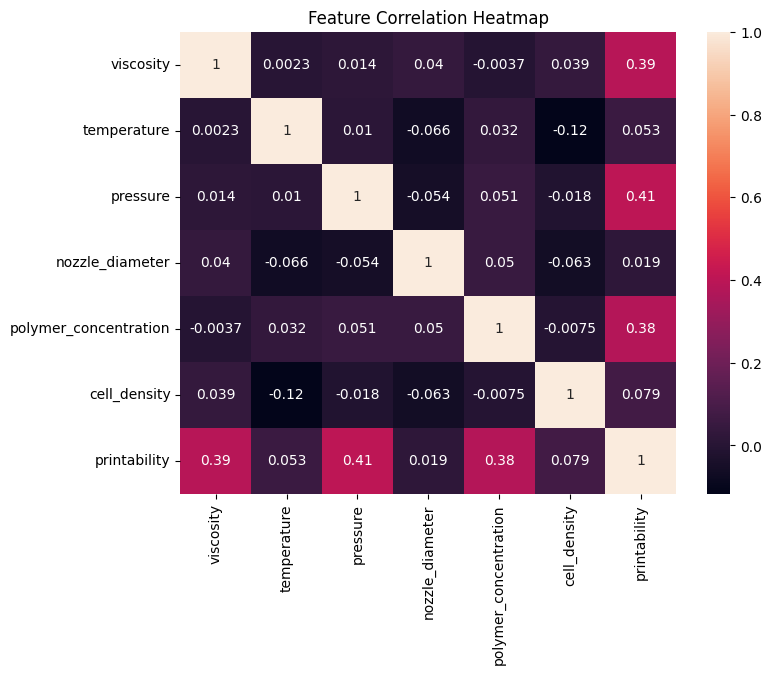

In [6]:
# STEP 5: Visualize correlations

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
# STEP 6: Separate input and output

# X = features
X = df.drop("printability", axis=1)

# y = target variable
y = df["printability"]

In [8]:
# STEP 7: Split dataset into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [9]:
# STEP 8: Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
# STEP 9: Check model accuracy

accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.99


In [11]:
# STEP 10: Test prediction manually

sample = [[30, 25, 40, 0.4, 3, 1.2]]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [12]:
# STEP 11: Save dataset file

df.to_csv("bioink_dataset.csv", index=False)

print("Dataset saved!")

Dataset saved!


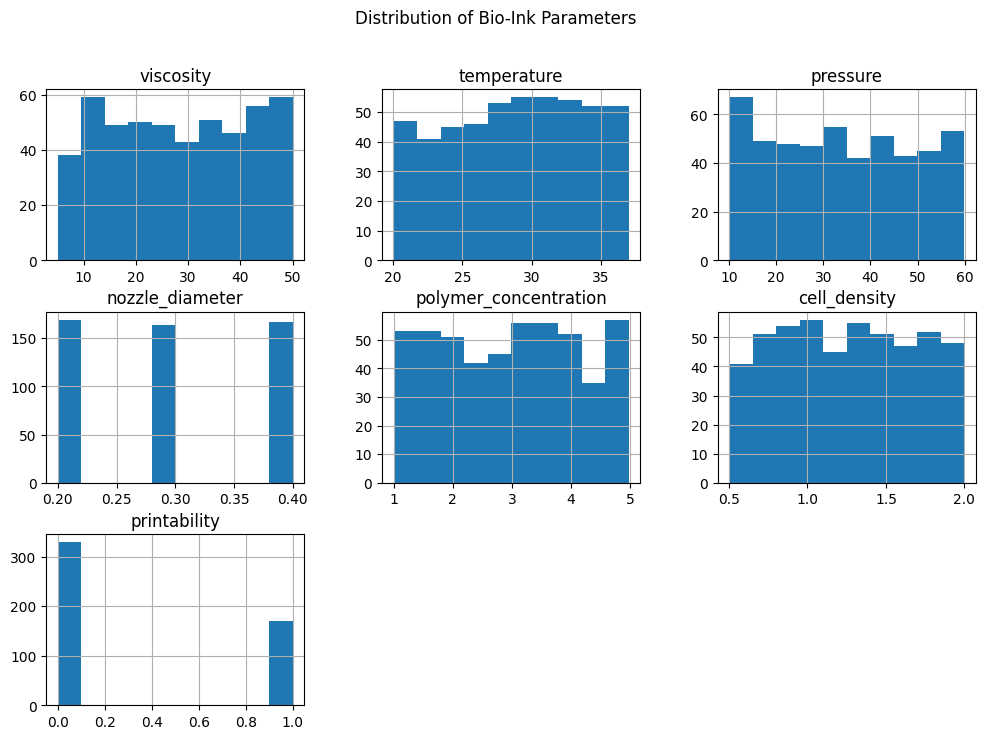

In [13]:
# VISUALIZATION 1: Feature distribution plots

df.hist(figsize=(12,8))

plt.suptitle("Distribution of Bio-Ink Parameters")

plt.show()

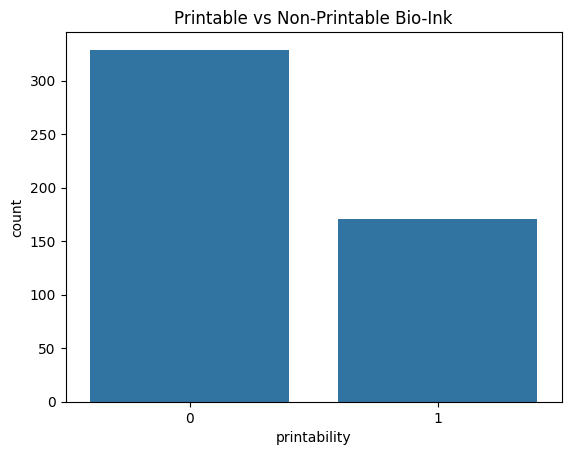

In [14]:
# VISUALIZATION 2: Count plot for output variable

sns.countplot(x="printability", data=df)

plt.title("Printable vs Non-Printable Bio-Ink")

plt.show()

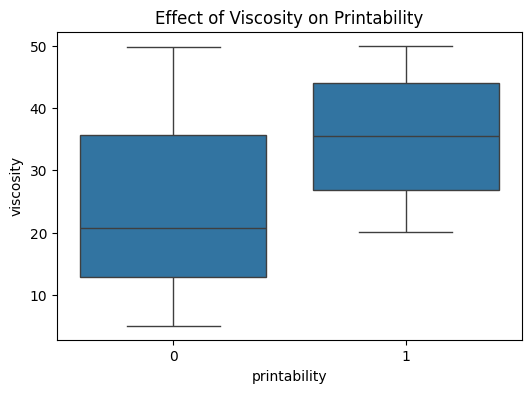

In [15]:
# VISUALIZATION 3: Viscosity vs printability

plt.figure(figsize=(6,4))

sns.boxplot(x="printability", y="viscosity", data=df)

plt.title("Effect of Viscosity on Printability")

plt.show()

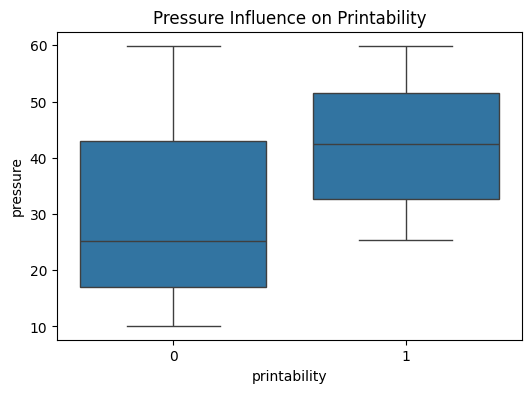

In [16]:
# VISUALIZATION 4: Pressure effect

plt.figure(figsize=(6,4))

sns.boxplot(x="printability", y="pressure", data=df)

plt.title("Pressure Influence on Printability")

plt.show()

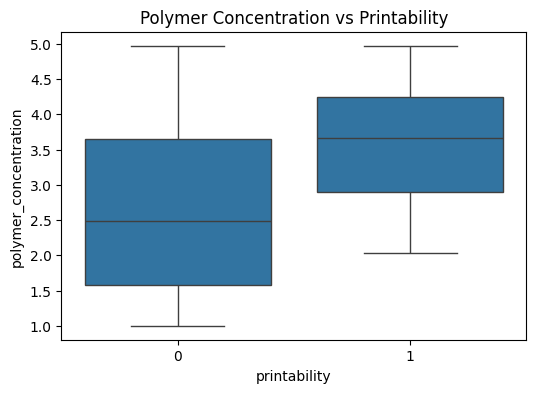

In [17]:
# VISUALIZATION 5: Polymer concentration impact

plt.figure(figsize=(6,4))

sns.boxplot(x="printability", y="polymer_concentration", data=df)

plt.title("Polymer Concentration vs Printability")

plt.show()

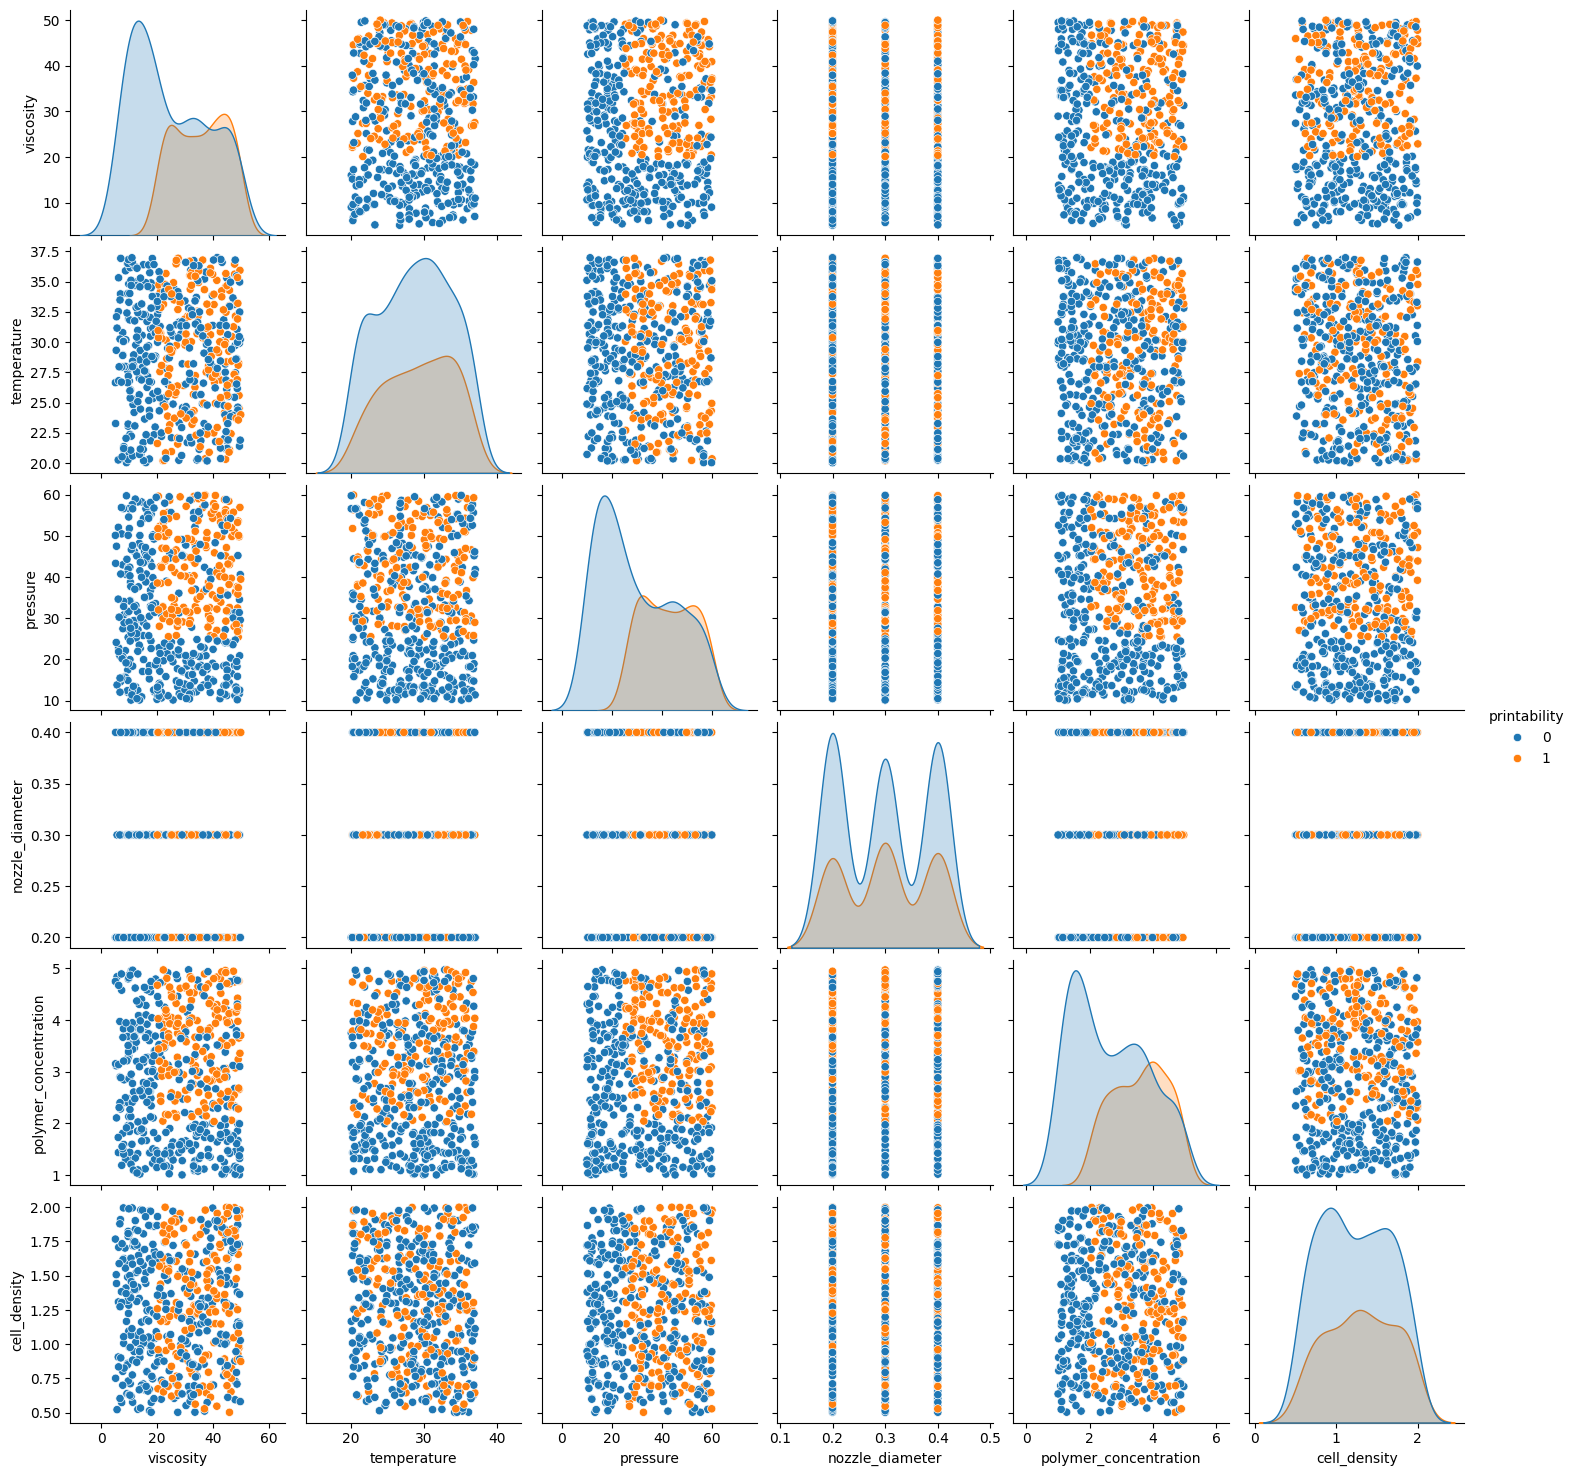

In [18]:
# VISUALIZATION 6: Pair plot

sns.pairplot(df, hue="printability")

plt.show()

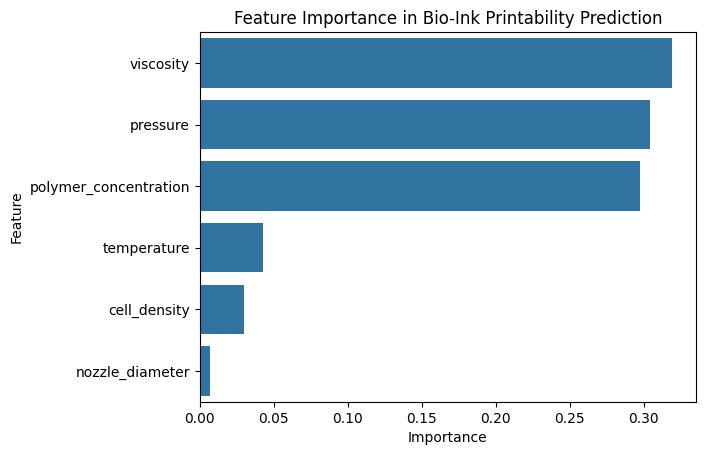

In [19]:
# VISUALIZATION 7: Feature importance

import pandas as pd

importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance_df)

plt.title("Feature Importance in Bio-Ink Printability Prediction")

plt.show()

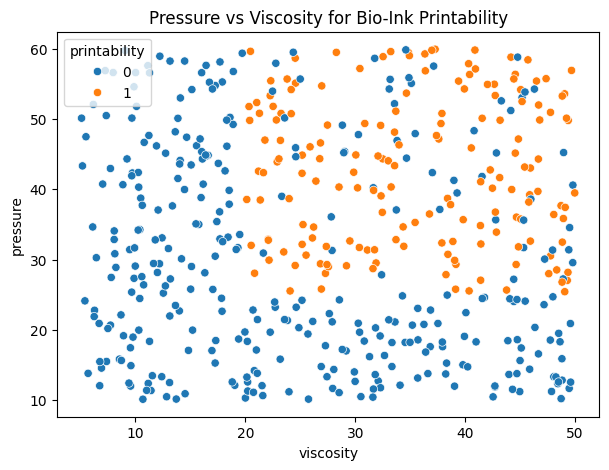

In [20]:
# ADVANCED VISUALIZATION 1: Pressure vs Viscosity

plt.figure(figsize=(7,5))

sns.scatterplot(
    x="viscosity",
    y="pressure",
    hue="printability",
    data=df
)

plt.title("Pressure vs Viscosity for Bio-Ink Printability")

plt.show()

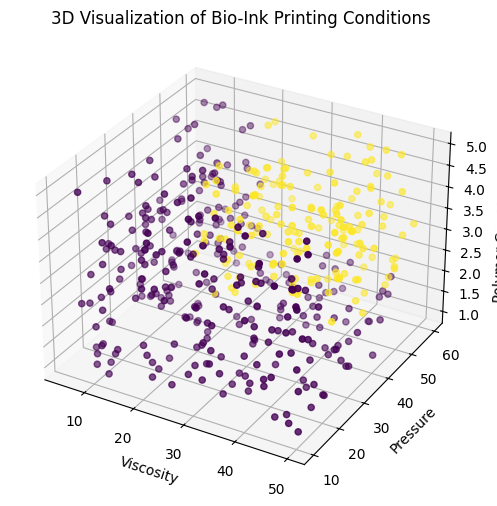

In [21]:
# ADVANCED VISUALIZATION 2: 3D scatter plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["viscosity"],
    df["pressure"],
    df["polymer_concentration"],
    c=df["printability"]
)

ax.set_xlabel("Viscosity")
ax.set_ylabel("Pressure")
ax.set_zlabel("Polymer Concentration")

plt.title("3D Visualization of Bio-Ink Printing Conditions")

plt.show()

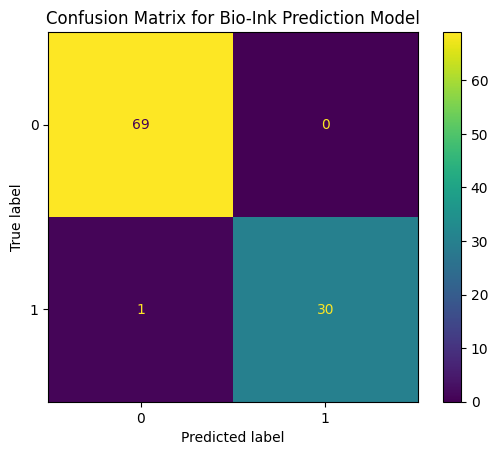

In [22]:
# ADVANCED VISUALIZATION 3: Confusion matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix for Bio-Ink Prediction Model")

plt.show()

In [23]:
# STEP 11: Save dataset file

df.to_csv("bioink_dataset.csv", index=False)

print("Dataset saved!")

Dataset saved!


In [24]:
# STEP 12: Save trained model

import joblib

joblib.dump(model, "bioink_model.pkl")

print("Model saved!")

Model saved!


In [25]:
# download dataset

from google.colab import files

files.download("bioink_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# download model

files.download("bioink_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>